# 🌱 AgroVis — Pipeline de Previsão de Seca

**Objetivo:** Prever, com 7 dias de antecedência, se uma região agrícola entrará em condição de seca extrema.

**Estratégia:** Classificação binária supervisionada utilizando dados meteorológicos históricos da NASA POWER API (2015–2026). A variável alvo (`ALVO_PREDITIVO`) é definida como `1` quando a umidade na raiz (`GWETROOT`) estará abaixo do percentil 20 histórico da região nos próximos 7 dias.

**Fluxo do pipeline:**
1. Extração — NASA POWER API
2. Transformação — limpeza, features e variável alvo
3. Análise Exploratória (EDA)
4. Treinamento — Random Forest com `class_weight='balanced'`
5. Avaliação — classification report e matriz de confusão

---
## 1. 📦 Configurações e imports

In [22]:
import requests
import numpy as np
import pandas as pd
import io
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

---
## 2. 🛰️ Extração — NASA POWER API

Coleta de dados meteorológicos diários para 11 localidades agrícolas estratégicas no Brasil, cobrindo o período de 2015 a 2026.

A API NASA POWER oferece dois endpoints relevantes:
- **`/point`** (Single Point): um ponto (lat × lon), aceita até 20 parâmetros por requisição.
- **`/regional`**: bounding box de área, aceita 1 parâmetro por requisição.

Utilizamos o endpoint `/point` para extração em lote.

### 2.1 Dicionário de dados — parâmetros da NASA POWER

In [23]:
# ----------------------------------------
# EXTRAÇÃO DE DADOS - CRIAÇÃO DO DICIONÁRIO DE DADOS
# ----------------------------------------

def get_parameter_details(parameters_df, parameter_short_names):
    """
    Busca os nomes completos e descrições dos parâmetros da NASA POWER
    a partir de uma lista de nomes abreviados.

    Args:
        parameter_short_names (list): Uma lista de strings com os nomes abreviados dos parâmetros.

    Returns:
        list: Uma lista de dicionários, onde cada dicionário contém
              'Short_Name', 'Parameter_Name' e 'Description' para cada parâmetro encontrado.
    """
    details = []
    for short_name in parameter_short_names:
        # Remove espaços em branco ou quebras de linha que possam ser lidas do código
        clean_short_name = short_name.strip()
        # Busca o parâmetro no DataFrame, usando 'ID' como o nome da coluna correto
        param_info = parameters_df[parameters_df['ID'] == clean_short_name]
        if not param_info.empty:
            details.append({
                'Short_Name': clean_short_name,
                'Parameter_Name': param_info['Name'].iloc[0],
                'Description': param_info['Description'].iloc[0]
            })
        else:
            details.append({
                'Short_Name': clean_short_name,
                'Parameter_Name': 'Não encontrado',
                'Description': 'Não encontrada'
            })
    return details

In [24]:
# ETAPA OPCIONAL: CRIAÇÃO DO DICIONÁRIO DE DADOS DE ACORDO COM DEFINIÇÃO OFICIAL
# Salva detalhes dos parâmetros em um DataFrame (criação de um dicionário de dados)

# Arquivo oficial da API contendo definição dos parâmetros a serem buscados
parameters_df = pd.read_csv('../docs/nasa-power-parameters.csv')

# Lista de parâmetros a serem pesquisados
AGRO_PARAMS = [
    "PRECTOTCORR",
    "GWETROOT",
    "GWETTOP",
    "T2M_MAX",
    "RH2M",
    "WS2M",
    "ALLSKY_SFC_SW_DWN",
    "ALLSKY_SFC_PAR_TOT"
]

param_details = get_parameter_details(parameters_df ,AGRO_PARAMS)

# Adiciona detalhes de Latitude e Longitude ao dicionário de dados
param_details.append({
    'Short_Name': 'LATITUDE',
    'Parameter_Name': 'Latitude',
    'Description': 'Latitude do ponto de coleta de dados.'
})
param_details.append({
    'Short_Name': 'LONGITUDE',
    'Parameter_Name': 'Longitude',
    'Description': 'Longitude do ponto de coleta de dados.'
})

df_params = pd.DataFrame(param_details)
os.makedirs("results", exist_ok=True)
col_desc_filename = "../docs/agrovis_columns_description.csv"
df_params.to_csv(col_desc_filename, index=False)
print(f"\nPronto! Arquivo de descrição de colunas estruturado e salvo como: {col_desc_filename}")
df_params.head()


Pronto! Arquivo de descrição de colunas estruturado e salvo como: ../docs/agrovis_columns_description.csv


,Short_Name,Parameter_Name,Description
0,PRECTOTCORR,Precipitation Corrected,The average MERRA-2 bias corrected total preci...
1,GWETROOT,Root Zone Soil Wetness,The amount of water and water vapor available ...
2,GWETTOP,Surface Soil Wetness,The amount of water and water vapor present in...
3,T2M_MAX,Temperature at 2 Meters Maximum,The maximum hourly air (dry bulb) temperature ...
4,RH2M,Relative Humidity at 2 Meters,The ratio of vapor pressure to the saturation ...


### 2.2 Função de extração

> **Nota de Arquitetura:** Para a extração em lote e treinamento, os metadados regionais (Cidade, Estado, Região) são injetados estaticamente via dicionário para otimizar o tempo de requisição. No ambiente de produção do AgroVis, a API de inferência receberá apenas coordenadas brutas (Lat/Lon) dos dispositivos IoT e utilizará uma camada de Geocodificação Reversa (ex: Nominatim/IBGE) para enriquecer o dado antes de passá-lo ao modelo.

In [25]:
# ----------------------------------------
# EXTRAÇÃO DE DADOS PARA PONTOS ÚNICOS (SINGLE POINT MODE)
# ----------------------------------------

# Existe dois endpoints diferentes da API que se relacionam com o projeto: /point e /regional
# /point ou Single Point: escolhe um ponto único (lat x long) para a busca. Aceita até 20 parâmetros por requisição.
# /regional ou Regional: cria um bounding box da área a ser analisada (lat min x long min x lat max x long max). Aceita 1 parâmetro por requisição.

def single_point_api_extract(params_to_search, latitude, longitude, start_date, end_date):
    """
    Coleta dados meteorológicos diários em um ponto único usando a API NASA POWER.

    Args:
        latitude (float): Latitude do ponto de interesse.
        longitude (float): Longitude do ponto de interesse.
        start_date (str): Data de início da coleta no formato YYYYMMDD (ex: '20250501').
        end_date (str): Data de fim da coleta no formato YYYYMMDD (ex: '20260501').

    Returns:
        pandas.DataFrame: Um DataFrame contendo os dados coletados, ou um DataFrame vazio em caso de falha.
    """
    # print(f"Iniciando a coleta de dados...")
    # print(f"Latitude:     {latitude}\n"
    #       f"Longitude:    {longitude}\n"
    #       f"Data InÍcio:  {start_date}\n"
    #       f"Data Fim:     {end_date}")

    url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    # Converte a lista de parâmetros para uma string separada por vírgulas
    params_string = ",".join(params_to_search)

    # Parâmetros da requisição à API NASA POWER para um ponto específico
    payload = {
        "latitude": latitude,       # Latitude do ponto de interesse
        "longitude": longitude,     # Longitude do ponto de interesse
        "start": start_date,        # Data de início da série temporal (YYYYMMDD)
        "end": end_date,            # Data de fim da série temporal (YYYYMMDD)
        "community": "ag",          # Comunidade de dados: 'ag' para aplicações agrícolas
        "parameters": params_string,
        "format": "csv",
        "units": "metric",          # Unidades das variáveis: 'metric' para unidades métricas (Celsius, mm, m/s)
        "header": "false",          # Incluir cabeçalho da resposta: 'false' para não incluir metadados adicionais da API no CSV, apenas os dados.
        "time-standard": "lst"      # Fuso horário: 'lst' para Local Standard Time (Hora Padrão Local)
    }

    # print("Enviando requisição para Nasa Power API...")
    response = requests.get(url, params=payload)

    if response.status_code == 200:
        df = pd.read_csv(io.StringIO(response.text))
        # print("O dataset foi extraído com sucesso!")
        return df

    else:
        print(f"Falha na requisição. Código de erro: {response.status_code}")
        print("Detalhe do erro:", response.text)
        return pd.DataFrame()

### 2.3 Execução — extração em lote e consolidação do dataset

In [26]:
# 1. Localidades estratégicas (Nome, Cidade, Estado, Região, Latitude, Longitude)
localidades_agro = [
    {"nome": "Sorriso_MT", "cidade": "Sorriso", "estado": "MT", "regiao": "Centro-Oeste", "lat": -12.54, "lon": -55.72},          # Polo da Soja (Cerrado)
    {"nome": "Petrolina_PE", "cidade": "Petrolina", "estado": "PE", "regiao": "Nordeste", "lat": -9.39, "lon": -40.50},           # Polo de Fruticultura (Semiárido)
    {"nome": "Ribeirao_Preto_SP", "cidade": "Ribeirão Preto", "estado": "SP", "regiao": "Sudeste", "lat": -21.17, "lon": -47.81}, # Polo da Cana (Sudeste)
    {"nome": "Dourados_MS", "cidade": "Dourados", "estado": "MS", "regiao": "Centro-Oeste", "lat": -22.22, "lon": -54.82},        # Grande produtor de grãos
    {"nome": "Uruacu_GO", "cidade": "Uruaçu", "estado": "GO", "regiao": "Centro-Oeste", "lat": -14.52, "lon": -48.86},            # Região com agricultura diversificada
    {"nome": "Passo_Fundo_RS", "cidade": "Passo Fundo", "estado": "RS", "regiao": "Sul", "lat": -28.27, "lon": -52.41},           # Trigo e Soja
    {"nome": "Cascavel_PR", "cidade": "Cascavel", "estado": "PR", "regiao": "Sul", "lat": -24.95, "lon": -53.45},                 # Milho e Soja
    {"nome": "Juazeiro_BA", "cidade": "Juazeiro", "estado": "BA", "regiao": "Nordeste", "lat": -9.42, "lon": -40.50},             # Fruticultura (similar a Petrolina)
    {"nome": "Santarem_PA", "cidade": "Santarém", "estado": "PA", "regiao": "Norte", "lat": -2.43, "lon": -54.71},                # Agricultura na Amazônia
    {"nome": "Eldorado_do_Sul_RS", "cidade": "Eldorado do Sul", "estado": "RS", "regiao": "Sul", "lat": -30.00, "lon": -51.61},   # FOCO DE INUNDAÇÃO (Tragédia RS)
    {"nome": "Cabrobo_PE", "cidade": "Cabrobó", "estado": "PE", "regiao": "Nordeste", "lat": -8.51, "lon": -39.30}                # FOCO DE SECA EXTREMA
]

lista_datasets_individuais = []

# Período a ser buscado
start_date = "20150101"
end_date = "20260401"

output_dir = "results/individual_data"
os.makedirs(output_dir, exist_ok=True)

print("Iniciando extração em lote da NASA POWER API...")

for loc in localidades_agro:
    print(f"Coletando dados de: {loc['nome']}...")

    df_temp = single_point_api_extract(AGRO_PARAMS, loc['lat'], loc['lon'], start_date, end_date)

    df_temp['CIDADE'] = loc['cidade']
    df_temp['ESTADO'] = loc['estado']
    df_temp['REGIAO'] = loc['regiao']
    df_temp['LATITUDE'] = loc['lat']
    df_temp['LONGITUDE'] = loc['lon']

    # Salva o dataset INVIDIDUAL
    nome_arquivo_individual = f"dataset_agrovis_{loc['nome']}_{loc['lat']}_{loc['lon']}.csv"
    df_temp.to_csv(os.path.join(output_dir, nome_arquivo_individual), index=False)
    # print(f" ✅ Arquivo individual da localidade salvo: {nome_arquivo_individual}")
    lista_datasets_individuais.append(df_temp)
    time.sleep(1)

# 2. Cria o Dataset UNIFICADO
print("\n🔄 Consolidando os dados em um único Dataset...")
df_unificado = pd.concat(lista_datasets_individuais, ignore_index=True)
consolidated_output_path = "results/dataset_agrovis_unificado.csv"
df_unificado.to_csv(consolidated_output_path, index=False)

print(f" Processo concluído! Dataset unificado criado com {df_unificado.shape[0]} linhas e {df_unificado.shape[1]} colunas.")

Iniciando extração em lote da NASA POWER API...
Coletando dados de: Sorriso_MT...
Coletando dados de: Petrolina_PE...
Coletando dados de: Ribeirao_Preto_SP...
Coletando dados de: Dourados_MS...
Coletando dados de: Uruacu_GO...
Coletando dados de: Passo_Fundo_RS...
Coletando dados de: Cascavel_PR...
Coletando dados de: Juazeiro_BA...
Coletando dados de: Santarem_PA...
Coletando dados de: Eldorado_do_Sul_RS...
Coletando dados de: Cabrobo_PE...

🔄 Consolidando os dados em um único Dataset...
 Processo concluído! Dataset unificado criado com 45199 linhas e 15 colunas.


In [27]:
df_unificado.head()

,YEAR,DOY,PRECTOTCORR,GWETROOT,GWETTOP,T2M_MAX,RH2M,WS2M,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_PAR_TOT,CIDADE,ESTADO,REGIAO,LATITUDE,LONGITUDE
0,2015,1,0.22,0.71,0.70,29.56,86.48,0.08,28.98,13.87,Sorriso,MT,Centro-Oeste,-12.54,-55.72
1,2015,2,0.38,0.70,0.68,30.42,80.85,0.23,25.49,12.42,Sorriso,MT,Centro-Oeste,-12.54,-55.72
2,2015,3,0.26,0.69,0.68,29.57,82.99,0.13,25.60,12.48,Sorriso,MT,Centro-Oeste,-12.54,-55.72
3,2015,4,2.13,0.69,0.69,29.81,82.91,0.08,27.79,13.34,Sorriso,MT,Centro-Oeste,-12.54,-55.72
4,2015,5,0.28,0.69,0.68,28.97,84.38,0.02,27.60,13.23,Sorriso,MT,Centro-Oeste,-12.54,-55.72


---
## 3. 🔨 Transformação — pipeline de dados

Sequência de transformações aplicadas via `.pipe()`:

| Etapa | Função | Descrição |
|---|---|---|
| 1 | `transform_date_columns` | Converte YEAR + DOY → DATA e ordena cronologicamente |
| 2 | `tratar_valores_nulos` | Substitui o padrão -999.0 da NASA por NaN e aplica forward/backward fill por localidade |
| 3 | `criar_features_temporais` | Cria acúmulos de chuva (7d, 30d), média de umidade (14d), ondas de calor e índice de estresse |
| 4 | `criar_variavel_alvo_dinamica_seca` | Define `ALVO_PREDITIVO` com shift de 7 dias (previsão do futuro) |
| 5 | `remover_colunas_intermediarias` | Extrai sazonalidade (MES_DO_ANO), remove colunas de metadados |

### 3.1 Definição das funções de transformação

In [28]:
def transform_date_columns(df_raw):
    """Transforma datas e garante a ordenação cronológica e espacial."""
    print("Transformando coluna de data 'DOY'...")
    df_transformed = df_raw.copy()
    if 'YEAR' in df_transformed.columns and 'DOY' in df_transformed.columns:
        df_transformed['DATA'] = pd.to_datetime(df_transformed['YEAR'] * 1000 + df_transformed['DOY'], format='%Y%j')
        df_transformed = df_transformed.sort_values(by=['LATITUDE', 'LONGITUDE', 'DATA']).reset_index(drop=True)
        df_transformed = df_transformed.drop(columns=['YEAR', 'DOY'])
    print(f"Transformação de data concluída.")
    return df_transformed

def tratar_valores_nulos(df):
    """Substitui o padrão -999.0 da NASA."""
    print("Iniciando tratamento de valores nulos e -999...")
    df_clean = df.copy()
    n_999_values = (df_clean == -999.0).sum().sum()
    print(f"Valores -999.0 encontrados antes do tratamento: {n_999_values}")
    df_clean.replace(-999.0, np.nan, inplace=True)
    initial_nans = df_clean.isnull().sum().sum()
    df_clean = df_clean.groupby(['LATITUDE', 'LONGITUDE'], group_keys=False).apply(lambda x: x.ffill().bfill(), include_groups=True)
    df_clean.reset_index(drop=True, inplace=True)
    final_nans = df_clean.isnull().sum().sum()
    print(f"Nulos restantes após tratamento: {final_nans}")
    print(f"Tratamento de nulos concluído.")
    return df_clean

def criar_features_temporais(df):
    """Cria indicadores agronômicos complexos baseados na interação das variáveis."""
    print("Criando features temporais...")
    df_feat = df.copy()

    # Acúmulos de Chuva
    df_feat['CHUVA_ACUM_7D'] = df_feat.groupby(['LATITUDE', 'LONGITUDE'])['PRECTOTCORR'].transform(lambda x: x.rolling(7, min_periods=1).sum())
    df_feat['CHUVA_ACUM_30D'] = df_feat.groupby(['LATITUDE', 'LONGITUDE'])['PRECTOTCORR'].transform(lambda x: x.rolling(30, min_periods=1).sum())

    # Média da Umidade da Raiz
    df_feat['MEDIA_GWETROOT_14D'] = df_feat.groupby(['LATITUDE', 'LONGITUDE'])['GWETROOT'].transform(lambda x: x.rolling(14, min_periods=1).mean())

    # Estresse e Calor
    df_feat['DIA_MUITO_QUENTE'] = (df_feat['T2M_MAX'] > 33.0).astype(int)
    df_feat['ONDAS_CALOR_7D'] = df_feat.groupby(['LATITUDE', 'LONGITUDE'])['DIA_MUITO_QUENTE'].transform(lambda x: x.rolling(7, min_periods=1).sum())
    df_feat['INDICE_ESTRESSE'] = df_feat['T2M_MAX'] / (df_feat['RH2M'] + 0.01)
    print(f"Features temporais criadas com sucesso.")
    return df_feat

def criar_variavel_alvo_dinamica_seca(df):
    """
    Cria a variável alvo BINÁRIA focada apenas em prever SECA.
    """
    print("Iniciando criação da variável alvo (seca ou não)...")
    df_out = df.sort_values(by=['LATITUDE', 'LONGITUDE', 'DATA']).copy()

    # Calcular apenas o limite de SECA de cada região (P20_GWETROOT)
    limiares = df_out.groupby(['LATITUDE', 'LONGITUDE']).agg(
        P20_GWETROOT=('GWETROOT', lambda x: x.quantile(0.20))
    ).reset_index()

    # Trazer o limiar de volta para o dataframe original
    df_out = df_out.merge(limiares, on=['LATITUDE', 'LONGITUDE'], how='left')

    # Definição do Target para Classificação Binária (0 = Normal, 1 = Seca Extrema local)
    df_out['EVENTO_HOJE'] = 0

    # Seca: Umidade na raiz abaixo do normal histórico da região
    condicao_seca = (df_out['GWETROOT'] <= df_out['P20_GWETROOT'])
    df_out.loc[condicao_seca, 'EVENTO_HOJE'] = 1

    # Deslocamento Temporal (Shift) de 7 dias para prever o futuro
    DIAS_FUTURO = 7
    df_out['ALVO_PREDITIVO'] = df_out.groupby(['LATITUDE', 'LONGITUDE'])['EVENTO_HOJE'].shift(-DIAS_FUTURO)

    # Limpeza de nulos causados pelo shift e conversão de tipo
    initial_rows = df_out.shape[0]
    df_out = df_out.dropna(subset=['ALVO_PREDITIVO'])
    print(f"{initial_rows - df_out.shape[0]} linhas removidas devido ao shift (ALVO_PREDITIVO NaN).")
    df_out['ALVO_PREDITIVO'] = df_out['ALVO_PREDITIVO'].astype(int)
    print("Distribuição do ALVO_PREDITIVO (0: Normal, 1: Seca) após criação:")
    print(df_out['ALVO_PREDITIVO'].value_counts())

    # Remover colunas auxiliares (Target Leakage)
    df_out = df_out.drop(columns=['P20_GWETROOT', 'EVENTO_HOJE'])
    print(f"Coluna de variável alvo criada com sucesso.")
    return df_out

def remover_colunas_intermediarias(df):
    """Prepara o dataset extraindo a sazonalidade e retendo a DATA para divisão futura."""
    print("Removendo colunas intermediárias...")
    df_final = df.copy()

    if 'DATA' in df_final.columns:
        df_final['MES_DO_ANO'] = df_final['DATA'].dt.month

    colunas_para_remover = ['CIDADE', 'ESTADO', 'REGIAO']
    df_final = df_final.drop(columns=[col for col in colunas_para_remover if col in df_final.columns], errors='ignore')
    print(f"Colunas intermediárias removidas.")
    return df_final

### 3.2 Execução do pipeline

In [29]:
# ==========================================
# EXECUÇÃO DA ESTEIRA (PIPELINE) E DIVISÃO TEMPORAL
# ==========================================

# Carrega os dados brutos
df_agrovis_raw = pd.read_csv(consolidated_output_path)

# Roda a transformação com o método pipe, definindo a previsão para 7 dias
df_preparado = (
    df_agrovis_raw
    .pipe(transform_date_columns)
    .pipe(tratar_valores_nulos)
    .pipe(criar_features_temporais)
    .pipe(criar_variavel_alvo_dinamica_seca)
    .pipe(remover_colunas_intermediarias)
)

Transformando coluna de data 'DOY'...
Transformação de data concluída.
Iniciando tratamento de valores nulos e -999...
Valores -999.0 encontrados antes do tratamento: 1015
Nulos restantes após tratamento: 0
Tratamento de nulos concluído.
Criando features temporais...
Features temporais criadas com sucesso.
Iniciando criação da variável alvo (seca ou não)...
77 linhas removidas devido ao shift (ALVO_PREDITIVO NaN).
Distribuição do ALVO_PREDITIVO (0: Normal, 1: Seca) após criação:
ALVO_PREDITIVO
0    33363
1    11759
Name: count, dtype: int64
Coluna de variável alvo criada com sucesso.
Removendo colunas intermediárias...
Colunas intermediárias removidas.


C:\Users\madeinweb\AppData\Local\Temp\ipykernel_6248\360275417.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_clean = df_clean.groupby(['LATITUDE', 'LONGITUDE'], group_keys=False).apply(lambda x: x.ffill().bfill(), include_groups=True)


In [30]:
df_preparado.head()

,PRECTOTCORR,GWETROOT,GWETTOP,T2M_MAX,RH2M,WS2M,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_PAR_TOT,LATITUDE,LONGITUDE,DATA,CHUVA_ACUM_7D,CHUVA_ACUM_30D,MEDIA_GWETROOT_14D,DIA_MUITO_QUENTE,ONDAS_CALOR_7D,INDICE_ESTRESSE,ALVO_PREDITIVO,MES_DO_ANO
0,17.43,0.71,0.77,26.50,93.67,1.36,8.78,4.53,-30.0,-51.61,2015-01-01,17.43,17.43,0.710000,0,0.0,0.282878,0,1
1,0.97,0.71,0.74,25.05,72.98,1.52,17.06,8.14,-30.0,-51.61,2015-01-02,18.40,18.40,0.710000,0,0.0,0.343198,0,1
2,0.00,0.70,0.72,27.50,72.47,1.11,27.52,12.61,-30.0,-51.61,2015-01-03,18.40,18.40,0.706667,0,0.0,0.379415,0,1
3,0.01,0.69,0.71,30.41,71.39,1.19,32.20,14.58,-30.0,-51.61,2015-01-04,18.41,18.41,0.702500,0,0.0,0.425910,0,1
4,0.01,0.68,0.69,31.15,76.36,1.53,31.28,14.27,-30.0,-51.61,2015-01-05,18.42,18.42,0.698000,0,0.0,0.407883,0,1


### 3.3 Divisão temporal — treino e teste

O dataset é dividido temporalmente (não aleatoriamente) para simular um cenário real de previsão:
- **Treino:** dados históricos até 31/12/2024
- **Teste:** dados de 01/01/2025 em diante (dados que o modelo nunca viu)

In [31]:
# Treinamento com dados de 2015 a 2024 e teste com 2025 em diante.
data_corte = pd.to_datetime('2025-01-01')

df_treino = df_preparado[df_preparado['DATA'] < data_corte]
df_teste = df_preparado[df_preparado['DATA'] >= data_corte]

X_treino = df_treino.drop(columns=['DATA', 'ALVO_PREDITIVO'])
y_treino = df_treino['ALVO_PREDITIVO']

X_teste = df_teste.drop(columns=['DATA', 'ALVO_PREDITIVO'])
y_teste = df_teste['ALVO_PREDITIVO']

# 4. Diagnóstico de Sucesso
print("✅ Transformação e Divisão Temporal concluídas com sucesso!")
print("-" * 50)
print(f"Registros de Treino (Passado - Até 2024): {X_treino.shape[0]}")
print(f"Registros de Teste  (Futuro  - 2025+):    {X_teste.shape[0]}")
print("-" * 50)
print("Distribuição do Alvo no Treino (0: Normal, 1: Seca):")
print(y_treino.value_counts())
print("-" * 50)

✅ Transformação e Divisão Temporal concluídas com sucesso!
--------------------------------------------------
Registros de Treino (Passado - Até 2024): 40183
Registros de Teste  (Futuro  - 2025+):    4939
--------------------------------------------------
Distribuição do Alvo no Treino (0: Normal, 1: Seca):
ALVO_PREDITIVO
0    30059
1    10124
Name: count, dtype: int64
--------------------------------------------------


---
## 4. 🔍 Análise exploratória (EDA)

Inspeção visual dos dados transformados antes do treinamento.

### 4.1 Estatísticas descritivas do dataset preparado

In [32]:
# ==========================================
# ESTATÍSTICAS BÁSICAS
# ==========================================
print("Estatísticas Descritivas do Dataset:")
display(df_preparado.describe())

Estatísticas Descritivas do Dataset:


,PRECTOTCORR,GWETROOT,GWETTOP,T2M_MAX,RH2M,WS2M,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_PAR_TOT,LATITUDE,LONGITUDE,DATA,CHUVA_ACUM_7D,CHUVA_ACUM_30D,MEDIA_GWETROOT_14D,DIA_MUITO_QUENTE,ONDAS_CALOR_7D,INDICE_ESTRESSE,ALVO_PREDITIVO,MES_DO_ANO
count,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000,45122.000000
mean,3.038002,0.663529,0.578954,30.636627,68.139797,2.100197,19.098488,8.897314,-16.674545,-49.062727,2020-08-12 12:00:00,21.247420,90.736682,0.663521,0.365210,2.554873,0.502765,0.260605,6.428571
min,0.000000,0.460000,0.090000,6.540000,13.110000,0.020000,0.700000,0.400000,-30.000000,-55.720000,2015-01-01 00:00:00,0.000000,0.000000,0.460000,0.000000,0.000000,0.068546,0.000000,1.000000
25%,0.010000,0.600000,0.390000,27.840000,56.230000,1.140000,15.650000,7.320000,-24.950000,-54.710000,2017-10-22 00:00:00,1.252500,18.080000,0.600000,0.000000,0.000000,0.333913,0.000000,3.000000
50%,0.240000,0.640000,0.620000,31.150000,70.090000,1.750000,19.590000,9.140000,-14.520000,-51.610000,2020-08-12 12:00:00,10.540000,70.860000,0.635714,0.000000,1.000000,0.443818,0.000000,6.000000
75%,2.720000,0.730000,0.750000,34.550000,81.990000,2.920000,23.180000,10.770000,-9.390000,-40.500000,2023-06-04 00:00:00,31.870000,139.037500,0.727857,1.000000,6.000000,0.609549,1.000000,9.000000
max,129.240000,1.000000,0.990000,42.980000,97.990000,7.020000,34.180000,15.070000,-2.430000,-39.300000,2026-03-25 00:00:00,300.340000,585.400000,0.991429,1.000000,7.000000,2.968750,1.000000,12.000000
std,6.860167,0.102887,0.216356,5.224127,16.438884,1.412638,5.930921,2.670760,8.678508,5.953369,NaN,27.325714,84.782204,0.101639,0.481494,2.914724,0.238895,0.438969,3.476734


### 4.2 Série temporal — dinâmica de chuva e umidade do solo

Visualização da relação entre precipitação (`PRECTOTCORR`) e umidade na raiz (`GWETROOT`) para uma localidade de exemplo nos últimos 365 dias.

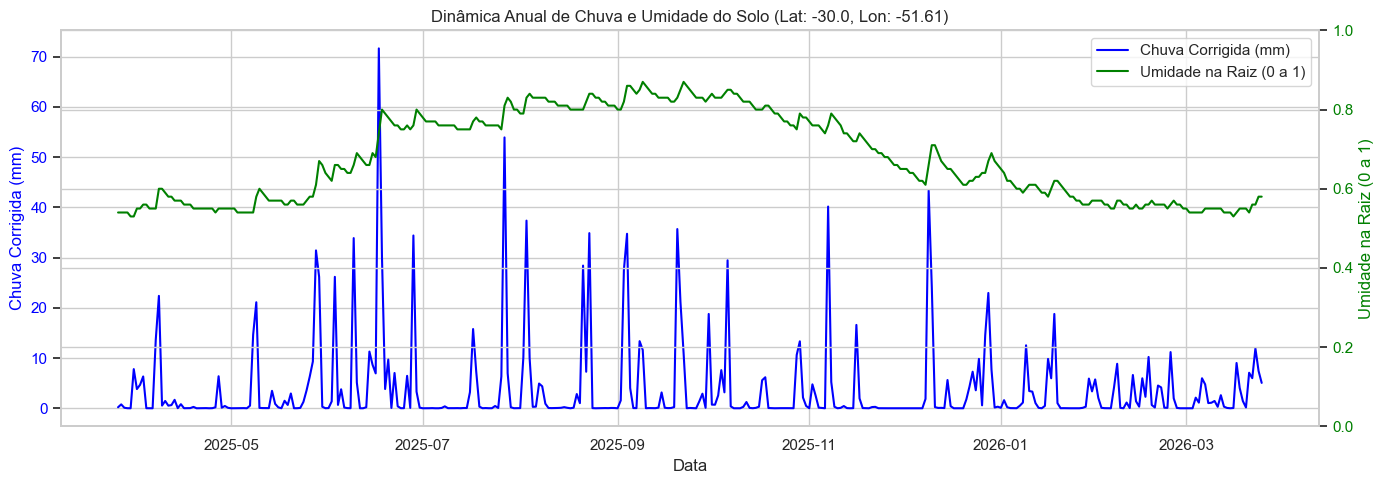

In [33]:
# Gráfico: Dinâmica de Chuva e Umidade (Série Temporal)
# Pegamos uma coordenada geográfica qualquer da base para ilustrar um ano de clima
lat_exemplo = df_preparado['LATITUDE'].unique()[0]
lon_exemplo = df_preparado['LONGITUDE'].unique()[0]

df_plot = df_preparado[
    (df_preparado['LATITUDE'] == lat_exemplo) &
    (df_preparado['LONGITUDE'] == lon_exemplo)
].tail(365)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Eixo esquerdo: Chuva
ax1.set_xlabel('Data')
ax1.set_ylabel('Chuva Corrigida (mm)', color='blue')
ax1.plot(df_plot['DATA'], df_plot['PRECTOTCORR'], color='blue', label='Chuva Corrigida (mm)')
ax1.tick_params(axis='y', labelcolor='blue')

# Eixo direito: Umidade
ax2 = ax1.twinx()
ax2.set_ylabel('Umidade na Raiz (0 a 1)', color='green')
ax2.plot(df_plot['DATA'], df_plot['GWETROOT'], color='green', label='Umidade na Raiz (0 a 1)')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_ylim(0, 1)

plt.title(f'Dinâmica Anual de Chuva e Umidade do Solo (Lat: {lat_exemplo}, Lon: {lon_exemplo})')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
plt.tight_layout()
plt.show()

### 4.3 Distribuição das classes no conjunto de treino

Análise do desbalanceamento entre a classe Normal (0) e Seca (1). O desbalanceamento justifica o uso de `class_weight='balanced'` no treinamento.

Gerando Análises Visuais...


C:\Users\madeinweb\AppData\Local\Temp\ipykernel_6248\1064889809.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_treino, palette='viridis')


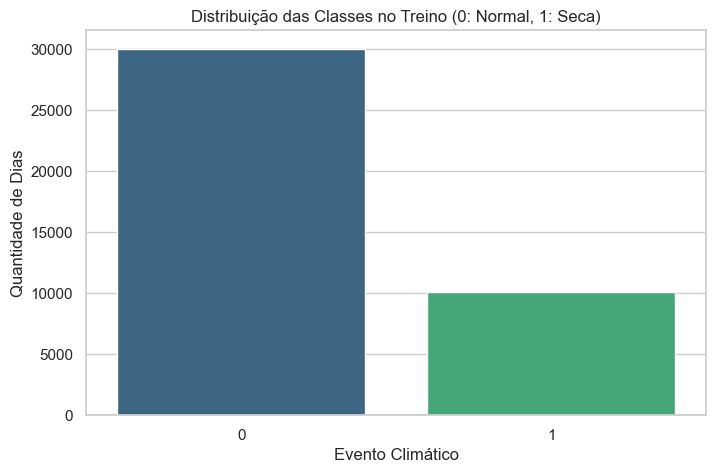

In [34]:
# ==========================================
# ANÁLISE EXPLORATÓRIA VISUAL (EDA)
# ==========================================
print("Gerando Análises Visuais...")
sns.set_theme(style="whitegrid")

# Ajuste do Gráfico A
plt.figure(figsize=(8, 5))
sns.countplot(x=y_treino, palette='viridis')
plt.title('Distribuição das Classes no Treino (0: Normal, 1: Seca)')
plt.xlabel('Evento Climático')
plt.ylabel('Quantidade de Dias')
plt.show()

---
## 5. 🤖 Treinamento do modelo

**Modelo:** Random Forest Classifier

**Decisões de design:**
- `class_weight='balanced'`: ajusta automaticamente os pesos das classes inversamente proporcional à sua frequência, compensando o desbalanceamento natural entre dias de seca e dias normais.
- `n_estimators=100`: 100 árvores de decisão no ensemble.
- `random_state=42`: garante reprodutibilidade.

In [35]:
# ==========================================
# TREINAMENTO DE MACHINE LEARNING
# ==========================================
print("Iniciando o treinamento dos modelos...")

# Modelo Principal: Random Forest
# O 'class_weight=balanced' lida automaticamente com a raridade das Secas
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_treino, y_treino)

# Modelo 2: KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_treino, y_treino)

print("✅ Treinamento Concluído com Sucesso!")

Iniciando o treinamento dos modelos...
✅ Treinamento Concluído com Sucesso!


---
## 6. 📊 Avaliação e métricas

Avaliação do modelo nos dados de **2025 em diante** — período que o modelo nunca viu durante o treinamento.

**Métricas principais para o contexto de seca:**
- **Recall (classe 1):** prioridade alta — falsos negativos (prever Normal quando é Seca) têm impacto direto na lavoura.
- **Precision (classe 1):** alertas falsos em excesso geram desconfiança no sistema.

### 6.1 Relatório de classificação

In [36]:
# ── Predições
y_pred_rf  = rf_model.predict(X_teste)
y_pred_knn = knn_model.predict(X_teste)

report_rf  = classification_report(y_teste, y_pred_rf,  target_names=['Normal', 'Seca'], zero_division=0, output_dict=True)
report_knn = classification_report(y_teste, y_pred_knn, target_names=['Normal', 'Seca'], zero_division=0, output_dict=True)

RESET = '\033[0m'; BOLD = '\033[1m'; DIM = '\033[2m'
VERDE = '\033[32m'; CINZA = '\033[90m'

def linha_comparacao(metrica, val_rf, val_knn):
    vencedor_rf  = val_rf >= val_knn
    tag_rf  = f"{VERDE}{BOLD}" if vencedor_rf  else CINZA
    tag_knn = f"{VERDE}{BOLD}" if not vencedor_rf else CINZA
    return (f"  {metrica:<22}"
            f"{tag_rf}{val_rf:.2f}{RESET}          "
            f"{tag_knn}{val_knn:.2f}{RESET}")

print(f"\n{BOLD}{'─'*52}{RESET}")
print(f"{BOLD}  COMPARAÇÃO DE MODELOS{RESET}")
print(f"{BOLD}  Conjunto de teste: 2025 em diante{RESET}")
print(f"{BOLD}{'─'*52}{RESET}")
print(f"  {'Métrica':<22}{'Random Forest':<18}{'KNN'}")
print(f"  {'─'*48}")
print(linha_comparacao("Accuracy",                report_rf['accuracy'],              report_knn['accuracy']))
print(linha_comparacao("Precision  (Seca)",       report_rf['Seca']['precision'],      report_knn['Seca']['precision']))
print(linha_comparacao("Recall     (Seca)",       report_rf['Seca']['recall'],         report_knn['Seca']['recall']))
print(linha_comparacao("F1-score   (Seca)",       report_rf['Seca']['f1-score'],       report_knn['Seca']['f1-score']))
print(linha_comparacao("Macro avg F1",            report_rf['macro avg']['f1-score'],  report_knn['macro avg']['f1-score']))
print(f"  {'─'*48}")
print(f"\n  {VERDE}{BOLD}Vencedor: Random Forest{RESET} {DIM}— melhor Recall e F1 na classe Seca,")
print(f"  métricas críticas para alertas agrícolas antecipados.{RESET}")
print(f"\n{BOLD}{'─'*52}{RESET}\n")


────────────────────────────────────────────────────
  COMPARAÇÃO DE MODELOS
  Conjunto de teste: 2025 em diante
────────────────────────────────────────────────────
  Métrica               Random Forest     KNN
  ────────────────────────────────────────────────
  Accuracy              0.88          0.82
  Precision  (Seca)     0.81          0.76
  Recall     (Seca)     0.85          0.65
  F1-score   (Seca)     0.83          0.70
  Macro avg F1          0.87          0.79
  ────────────────────────────────────────────────

  Vencedor: Random Forest — melhor Recall e F1 na classe Seca,
  métricas críticas para alertas agrícolas antecipados.

────────────────────────────────────────────────────



In [37]:
RESET = '\033[0m'; BOLD = '\033[1m'; DIM = '\033[2m'
cores = {'Normal': '\033[34m', 'Seca': '\033[32m'}

print(f"\n{BOLD}{'─'*52}{RESET}")
print(f"{BOLD}  AVALIAÇÃO DETALHADA — RANDOM FOREST{RESET}")
print(f"{BOLD}{'─'*52}{RESET}\n")

for cls in ['Normal', 'Seca']:
    m   = report_rf[cls]
    cor = cores[cls]
    bar_p = '█' * round(m['precision'] * 20); pad_p = '░' * (20 - len(bar_p))
    bar_r = '█' * round(m['recall']    * 20); pad_r = '░' * (20 - len(bar_r))
    bar_f = '█' * round(m['f1-score']  * 20); pad_f = '░' * (20 - len(bar_f))

    print(f"  {cor}{BOLD}Classe: {cls}{RESET}  {DIM}({int(m['support'])} amostras){RESET}")
    print(f"  {'─'*48}")
    print(f"  Precision  {cor}{bar_p}{RESET}{DIM}{pad_p}{RESET}  {cor}{BOLD}{m['precision']:.2f}{RESET}")
    print(f"  {DIM}  → De todos os alertas emitidos, {m['precision']*100:.0f}% eram corretos{RESET}")
    print()
    print(f"  Recall     {cor}{bar_r}{RESET}{DIM}{pad_r}{RESET}  {cor}{BOLD}{m['recall']:.2f}{RESET}")
    print(f"  {DIM}  → De todos os casos reais, {m['recall']*100:.0f}% foram detectados{RESET}")
    print()
    print(f"  F1-score   {cor}{bar_f}{RESET}{DIM}{pad_f}{RESET}  {cor}{BOLD}{m['f1-score']:.2f}{RESET}")
    print(f"  {DIM}  → Equilíbrio entre Precision e Recall{RESET}")
    print(f"\n  {'─'*48}\n")

print(f"  {BOLD}Métricas globais{RESET}")
print(f"  {'─'*48}")
print(f"  Accuracy          {BOLD}{report_rf['accuracy']:.2f}{RESET}  {DIM}(acertos sobre total){RESET}")
print(f"  Macro avg F1      {BOLD}{report_rf['macro avg']['f1-score']:.2f}{RESET}  {DIM}(média igual entre classes){RESET}")
print(f"  Weighted avg F1   {BOLD}{report_rf['weighted avg']['f1-score']:.2f}{RESET}  {DIM}(ponderado pelo nº de amostras){RESET}")
print(f"\n{BOLD}{'─'*52}{RESET}\n")


────────────────────────────────────────────────────
  AVALIAÇÃO DETALHADA — RANDOM FOREST
────────────────────────────────────────────────────

  Classe: Normal  (3304 amostras)
  ────────────────────────────────────────────────
  Precision  ██████████████████░░  0.92
    → De todos os alertas emitidos, 92% eram corretos

  Recall     ██████████████████░░  0.90
    → De todos os casos reais, 90% foram detectados

  F1-score   ██████████████████░░  0.91
    → Equilíbrio entre Precision e Recall

  ────────────────────────────────────────────────

  Classe: Seca  (1635 amostras)
  ────────────────────────────────────────────────
  Precision  ████████████████░░░░  0.81
    → De todos os alertas emitidos, 81% eram corretos

  Recall     █████████████████░░░  0.85
    → De todos os casos reais, 85% foram detectados

  F1-score   █████████████████░░░  0.83
    → Equilíbrio entre Precision e Recall

  ────────────────────────────────────────────────

  Métricas globais
  ───────────────────

### 6.2 Matriz de confusão

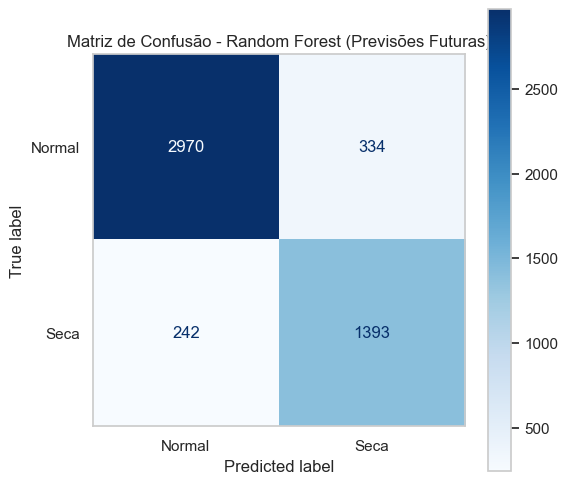

In [38]:
# Matriz de Confusão
cm = confusion_matrix(y_teste, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Seca'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Random Forest (Previsões Futuras)')
plt.grid(False) # Remove linhas de grade por cima do gráfico
plt.show()